In [1]:
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import matplotlib
import statsmodels
print("All good!")


All good!


In [2]:
# Basic imports
import pandas as pd
import numpy as np

# Stats & models
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Plots
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('./remote_work_productivity_modified.csv')
df.head()

,Employee_ID,Employment_Type,Hours_Worked_Per_Week,Productivity_Score,Well_Being_Score
0,1,Hybrid,29,75,78
1,2,In-Office,45,49,47
2,3,Hybrid,34,74,89
3,4,Remote,25,81,84
4,5,Remote,50,70,74


In [5]:
df.shape

(1000, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Employee_ID            1000 non-null   int64 
 1   Employment_Type        1000 non-null   object
 2   Hours_Worked_Per_Week  1000 non-null   int64 
 3   Productivity_Score     1000 non-null   int64 
 4   Well_Being_Score       1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [7]:
df.describe()

,Employee_ID,Hours_Worked_Per_Week,Productivity_Score,Well_Being_Score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,39.720000,68.602000,63.975000
std,288.819436,8.042779,12.235494,13.870572
min,1.000000,16.000000,33.000000,14.000000
25%,250.750000,34.750000,60.000000,56.000000
50%,500.500000,40.000000,68.000000,65.000000
75%,750.250000,45.000000,76.000000,73.000000
max,1000.000000,64.000000,112.000000,104.000000


In [8]:
# Standardize Employment_Type text
df['Employment_Type'] = df['Employment_Type'].astype(str).str.strip().str.title()
df['Employment_Type'] = df['Employment_Type'].replace({
    'In Office': 'In-Office',
    'In-Office': 'In-Office',
    'Inoffice': 'In-Office',
    'Remote': 'Remote',
    'Work From Home': 'Remote',
    'Wfh': 'Remote',
    'Hybrid': 'Hybrid'
})

# Confirm categories and counts
print(df['Employment_Type'].value_counts())


Employment_Type
In-Office    510
Remote       404
Hybrid        86
Name: count, dtype: int64


In [9]:
# Missing values
print('Missing values per column:\n', df.isnull().sum())

# If small number of missing values, drop; else impute with median for numeric
# Example strategy:
num_cols = ['Hours_Worked_Per_Week','Productivity_Score','Well_Being_Score']
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].median(), inplace=True)

# If any Employment_Type missing, drop those rows (rare)
df = df[~df['Employment_Type'].isin(['nan','None','NoneType'])]


Missing values per column:
 Employee_ID              0
Employment_Type          0
Hours_Worked_Per_Week    0
Productivity_Score       0
Well_Being_Score         0
dtype: int64


In [10]:
# Ensure ranges are sensible
df = df[(df['Hours_Worked_Per_Week'] >= 0) & (df['Hours_Worked_Per_Week'] <= 100)]
df = df[(df['Productivity_Score'] >= 0) & (df['Productivity_Score'] <= 100)]
df = df[(df['Well_Being_Score'] >= 0) & (df['Well_Being_Score'] <= 100)]

# Final counts
print('Final sample size:', len(df))
df['Employment_Type'].value_counts()


Final sample size: 985


,count
Employment_Type,
In-Office,509
Remote,390
Hybrid,86


In [11]:
group_summary = df.groupby('Employment_Type').agg(
    N=('Employee_ID','count'),
    Mean_Productivity=('Productivity_Score','mean'),
    SD_Productivity=('Productivity_Score','std'),
    Mean_Hours=('Hours_Worked_Per_Week','mean'),
    SD_Hours=('Hours_Worked_Per_Week','std'),
    Mean_WellBeing=('Well_Being_Score','mean'),
    SD_WellBeing=('Well_Being_Score','std')
).reset_index()
group_summary


,Employment_Type,N,Mean_Productivity,SD_Productivity,Mean_Hours,SD_Hours,Mean_WellBeing,SD_WellBeing
0,Hybrid,86,71.348837,11.925028,34.860465,6.911479,70.186047,8.208334
1,In-Office,509,63.789784,9.840510,44.430255,5.927843,58.583497,14.717129
2,Remote,390,73.007692,11.263721,34.820513,6.985743,69.443590,10.508689


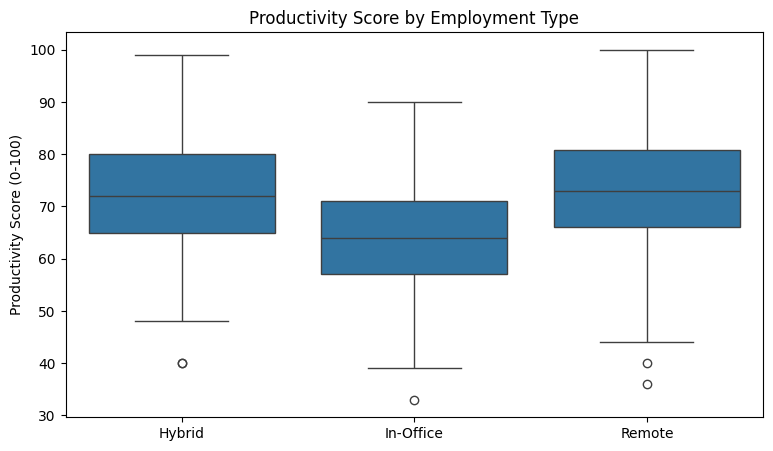

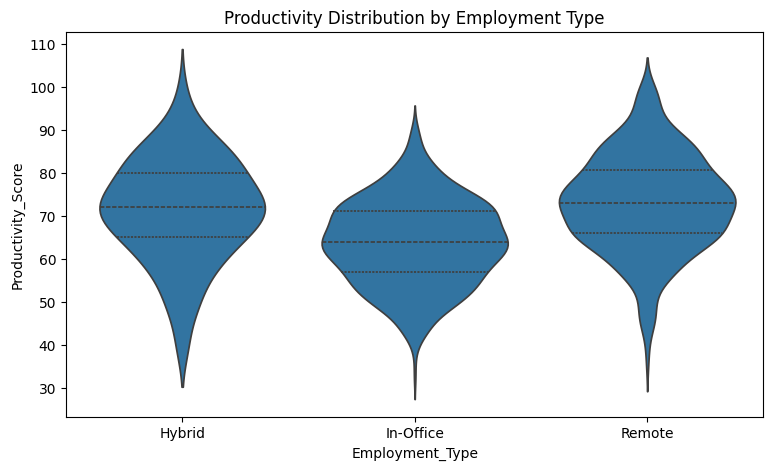

In [12]:
plt.figure(figsize=(9,5))
sns.boxplot(x='Employment_Type', y='Productivity_Score', data=df)
plt.title('Productivity Score by Employment Type')
plt.ylabel('Productivity Score (0-100)')
plt.xlabel('')
plt.show()

plt.figure(figsize=(9,5))
sns.violinplot(x='Employment_Type', y='Productivity_Score', data=df, inner='quartile')
plt.title('Productivity Distribution by Employment Type')
plt.show()


In [15]:
model = smf.ols('Productivity_Score ~ C(Employment_Type)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                           sum_sq     df          F        PR(>F)
C(Employment_Type)   19757.231063    2.0  87.684496  9.163595e-36
Residual            110633.018683  982.0        NaN           NaN


The ANOVA table shows that there is a statistically significant difference in `Productivity_Score` among the `Employment_Type` groups (p < 0.001). This suggests that at least one employment type has a different mean productivity score than the others. Now, let's perform a post-hoc Tukey HSD test to identify which specific groups are different.

In [16]:
tukey_result = pairwise_tukeyhsd(endog=df['Productivity_Score'], groups=df['Employment_Type'], alpha=0.05)
print(tukey_result)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
   Hybrid In-Office  -7.5591    0.0 -10.4637 -4.6544   True
   Hybrid    Remote   1.6589 0.3888  -1.3092  4.6269  False
In-Office    Remote   9.2179    0.0   7.5413 10.8945   True
-----------------------------------------------------------


The Tukey HSD post-hoc test indicates the following:

*   **Hybrid vs. In-Office**: There is a significant difference (p < 0.001). Hybrid employees have a higher mean productivity score than In-Office employees.
*   **Hybrid vs. Remote**: There is no significant difference (p = 0.508). The mean productivity scores for Hybrid and Remote employees are not significantly different.
*   **In-Office vs. Remote**: There is a significant difference (p < 0.001). Remote employees have a higher mean productivity score than In-Office employees.

In summary, In-Office employees tend to have significantly lower productivity scores compared to both Hybrid and Remote employees, while there's no significant difference between Hybrid and Remote groups.